# Gradient Boosting Vlatility Model

This notebook will train a Gradient Boosting regression model to predict future 20-day realized volatility.

The goal will be to compare a stronger non-linear model against the baseline model and the linear model. 

Gradient Boosing is useful becaue it builds many small decision trees one after another, where each new tree tries to fix the errors from the previous trees.

# Imports

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# ENUMS Path 

In [2]:
FEATURE_DATA_PATH = Path("../data/processed/features")

# Import Data CSV

In [4]:
df = pd.read_csv(
    FEATURE_DATA_PATH / "feature_engineered_dataset.csv",
    parse_dates=['Date']
)

# Feature and Target Selection

In [5]:
FEATURES_COLS = [
    "return_lag_1",
    "return_lag_5",
    "rolling_return_5d",
    "rolling_return_20d",
    "abs_return",
    "squared_return",
    "rolling_abs_return_20d",
    "rolling_squared_return_20d",
    "rolling_volatility_5d",
    "rolling_volatility_20d",
    "price_to_moving_avg_20d",
    "risk_free_rate_decimal",
    "cpi_pct_change"
]

In [6]:
TARGET_COLS = "future_volatility_20d"

# Train/Test Split Separation

In [7]:
train = df[df["Date"] < "2024-01-01"].copy()
test = df[df["Date"] >= "2024-01-01"].copy()

X_train = train[FEATURES_COLS]
y_train = train[TARGET_COLS]

X_test = test[FEATURES_COLS]
y_test = test[TARGET_COLS]

# Create Baseline

In [8]:
baseline_pred = test["rolling_volatility_20d"]

# Train Gradient Boosting Model

In [9]:
gb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=42
)

In [10]:
gb_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",200
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.01
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [11]:
gb_pred = gb_model.predict(X_test)

# Reuse Evaluation Model

In [13]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Create Results Table

In [14]:
results = pd.DataFrame([
    evaluate_model("Baseline: rolling_volatility_20d", y_test, baseline_pred),
    evaluate_model("Gradient Boosting", y_test, gb_pred)
])

results

,model,MAE,RMSE,R2
0,Baseline: rolling_volatility_20d,0.004647,0.007130,0.001510
1,Gradient Boosting,0.003990,0.006049,0.281369


# Prediction Output Table

In [15]:
prediction_results = test[["Date", "ticker", "future_volatility_20d", "rolling_volatility_20d"]].copy()

prediction_results["gradient_boosting_prediction"] = gb_pred
prediction_results["absolute_error"] = (
    prediction_results["future_volatility_20d"] 
    - prediction_results["gradient_boosting_prediction"]
).abs()

prediction_results.head()

,Date,ticker,future_volatility_20d,rolling_volatility_20d,gradient_boosting_prediction,absolute_error
1489,2024-01-02,AAPL,0.013366,0.012075,0.013921,0.000555
1490,2024-01-03,AAPL,0.013582,0.012014,0.013882,0.000299
1491,2024-01-04,AAPL,0.013296,0.011036,0.012771,0.000525
1492,2024-01-05,AAPL,0.013373,0.011021,0.012846,0.000527
1493,2024-01-08,AAPL,0.012426,0.012272,0.013511,0.001086


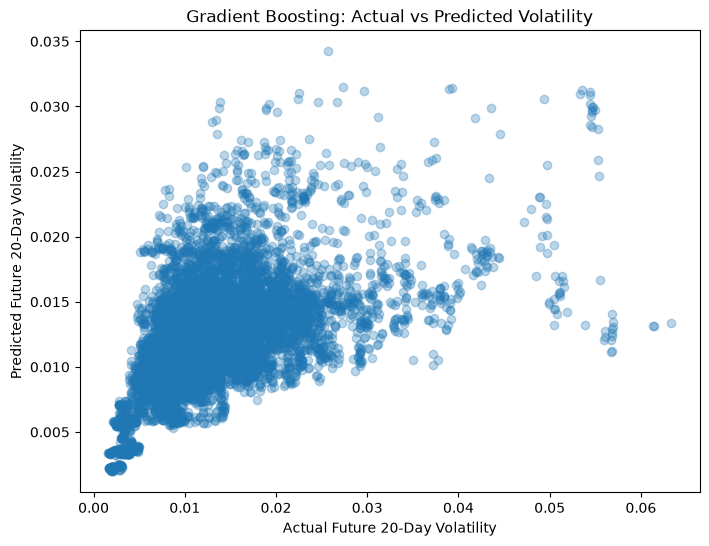

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, gb_pred, alpha=0.3)

plt.xlabel("Actual Future 20-Day Volatility")
plt.ylabel("Predicted Future 20-Day Volatility")
plt.title("Gradient Boosting: Actual vs Predicted Volatility")

plt.show()